# gnomAD population-frequency EDA

gnomAD v4 (`gnomad_r4`) allele frequencies at expert-reviewed ClinVar SNVs.

Pipeline:

```
python src/ingest_gnomad.py       # data/raw/gnomad_clinvar_sites.parquet
python src/clean_gnomad.py        # data/processed/gnomad_clean.parquet
python src/join_clinvar_gnomad.py # + --vus
```

Preferred AF is **joint** (exomes+genomes), then exome, then genome. Sites absent from gnomAD stay `in_gnomad=False`.

These frequencies are **EDA-only** — they are not in the training matrix.

**Circularity:** ClinVar pathogenic/benign labels already use population frequency (BA1/BS1/PM2). A large AF-vs-label split is expected and is not independent biological signal.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

In [2]:
load_dotenv()
project_root = Path(os.environ["PROJECT_ROOT"])
sys.path.insert(0, str(project_root / "src"))

from features import add_gnomad_features, prepare_modeling_frame

GNOMAD_CLEAN = project_root / "data/processed/gnomad_clean.parquet"
JOINED = project_root / "data/processed/clinvar_uniprot_gnomad_position_matched.parquet"

In [3]:
gnomad = pd.read_parquet(GNOMAD_CLEAN)
gnomad.shape, gnomad["in_gnomad"].mean()

((15241, 64), np.float64(0.6375565907748836))

In [4]:
print(gnomad["in_gnomad"].value_counts().to_string())
print("filter_pass:", gnomad["gnomad_filter_pass"].value_counts().to_dict())
found = gnomad.loc[gnomad["in_gnomad"], "gnomad_af"]
found.describe(percentiles=[0.5, 0.9, 0.99])

in_gnomad
True     9717
False    5524
filter_pass: {True: 7653, False: 7588}


count    9717.000000
mean        0.019463
std         0.091779
min         0.000000
50%         0.000009
90%         0.007176
99%         0.491995
max         0.999517
Name: gnomad_af, dtype: float64

## AF vs ClinVar label

One row per labelled variant after the UniProt position-match + gnomAD join.

In [5]:
joined = pd.read_parquet(JOINED)
model = add_gnomad_features(prepare_modeling_frame(joined))
print(model.shape)
model.groupby("label").agg(
    n=("VariationID", "size"),
    pct_in_gnomad=("in_gnomad", "mean"),
    median_af=("gnomad_af", "median"),
    mean_log10_af=("log10_gnomad_af", "mean"),
    pct_filter_pass=("gnomad_filter_pass", "mean"),
)

(11563, 99)


,n,pct_in_gnomad,median_af,mean_log10_af,pct_filter_pass
label,,,,,
benign,5211,0.905392,0.000059,-3.887700,0.619075
pathogenic,6352,0.454030,0.000000,-5.700946,0.401763


In [6]:
print(model["gnomad_af_bin"].value_counts().to_string())
pd.crosstab(model["gnomad_af_bin"], model["label"], normalize="index").round(3)

gnomad_af_bin
absent                  3961
singleton_or_private    3611
ultra_rare              1491
rare                     910
low_freq                 754
common_ba1               547
common_bs1               289


label,benign,pathogenic
gnomad_af_bin,,
absent,0.124,0.876
common_ba1,1.000,0.000
common_bs1,0.997,0.003
low_freq,0.977,0.023
rare,0.904,0.096
singleton_or_private,0.365,0.635
ultra_rare,0.674,0.326


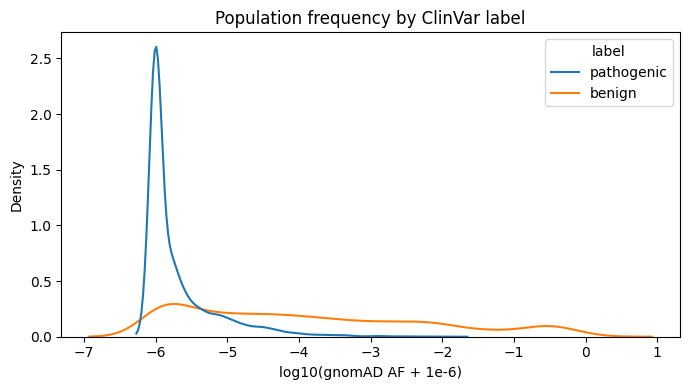

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(
    data=model, x="log10_gnomad_af", hue="label",
    common_norm=False, ax=ax,
)
ax.set_xlabel("log10(gnomAD AF + 1e-6)")
ax.set_title("Population frequency by ClinVar label")
plt.tight_layout()
plt.show()

## Derived AF columns (EDA only)

`add_gnomad_features()` builds these for plots. They are **not** in `FEATURE_COLUMNS` / training.

| column | type | notes |
|---|---|---|
| `log10_gnomad_af` | numeric | joint AF, absent → 0 before log |
| `log10_gnomad_af_popmax` | numeric | filtering AF (FAF95) when available |
| `log1p_gnomad_nhomalt` | numeric | log1p(homozygote count) |
| `in_gnomad` | bool | present in gnomAD v4 sites |
| `gnomad_filter_pass` | bool | empty FILTER on available sources |
| `gnomad_af_bin` | categorical | absent / singleton_or_private / ultra_rare / rare / low_freq / common_bs1 / common_ba1 |

`gnomad_an` is kept on the joined table for EDA (gene-coverage proxy; omitted from models for the same reason as Length).